# Customer Behavior EDA (Legacy Monolith)

This notebook is retained for reference.

Split notebooks for active work:
- `02a_customer_kpi_segments.ipynb`
- `02b_customer_retention_clv.ipynb`
- `02c_customer_trends_diagnostics.ipynb`

## Notebook Roadmap

1. Data Setup & KPI Baseline
2. Bivariate Behavior Comparison
3. Time-slot Pattern (Day x Hour)
4. Customer Segmentation (User-level)
5. Segment Preferences (Product / Aisle)
6. Retention & Churn
7. Basket Value by Category
8. CLV Trends & Segment CLV
9. Extra Diagnostics (Funnel / Gateway / Trend / Histogram)
10. Executive Summary

Run guide:
- ตั้งค่า `USE_SAMPLE` ที่ cell โหลดข้อมูล
- รันจากบนลงล่างเพื่อให้ตัวแปรกลาง (เช่น `rfm`, `segment_txn`, `customer_monthly`) พร้อมใช้งานครบ

In [1]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# --- Display formatting (readable numbers in notebook output) ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# --- Notebook output controls (clean vs verbose mode) ---
SHOW_VERBOSE_TABLES = False
PREVIEW_ROWS = 10

def show_df(df, title=None, n=PREVIEW_ROWS):
    """Display full table only in verbose mode; otherwise show top-N preview."""
    if title:
        print(title)
    display(df if SHOW_VERBOSE_TABLES else df.head(n))

# --- Configuration ---
# set USE_SAMPLE = True for quick testing, False for full dataset analysis
USE_SAMPLE = False

# Setup project path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload the loader module so notebook execution always uses the latest code.
import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

df = data_access_module.load_customer_behavior_data(
    use_sample=USE_SAMPLE,
    project_root=PROJECT_ROOT,
)

print(f"Loaded {len(df):,} records with {df['user_id'].nunique():,} unique customers")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
print(f"Columns: {list(df.columns)}\n")
df.head()

Loaded 32,434,489 records with 206,209 unique customers
Date range: 2014-07-01 to 2015-07-01
Data mode: FULL DATASET
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'cumulative_days', 'order_date', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department', 'total_price', 'cumulative_reorder_per_customer']



,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,cumulative_days,order_date,product_name,aisle_id,department_id,aisle,department,total_price,cumulative_reorder_per_customer
0,2539329,196,1,0,1,prior,1,2,8,0.0,0.0,2014-12-23,Soda,77,7,soft drinks,beverages,1,0
1,2539329,14084,2,0,1,prior,1,2,8,0.0,0.0,2014-12-23,Organic Unsweetened Vanilla Almond Milk,91,16,soy lactosefree,dairy eggs,1,0
2,2539329,12427,3,0,1,prior,1,2,8,0.0,0.0,2014-12-23,Original Beef Jerky,23,19,popcorn jerky,snacks,1,0
3,2539329,26088,4,0,1,prior,1,2,8,0.0,0.0,2014-12-23,Aged White Cheddar Popcorn,23,19,popcorn jerky,snacks,1,0
4,2539329,26405,5,0,1,prior,1,2,8,0.0,0.0,2014-12-23,XL Pick-A-Size Paper Towel Rolls,54,17,paper goods,household,1,0


## 1) Data Setup & KPI Baseline

**Data Mode Configuration**
- `USE_SAMPLE = False` สำหรับ full dataset (production)
- `USE_SAMPLE = True` สำหรับ quick test (development)

ส่วนนี้ใช้ตั้งค่า environment และสร้าง baseline KPI ต่อผู้ใช้เพื่อดูภาพรวมก่อนลงลึก

In [2]:
customer_kpi = (
    df.groupby("user_id")
    .agg(
        total_orders=("order_number", "max"),
        total_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        cumulative_reorder_last=("cumulative_reorder_per_customer", "max"),
    )
    .reset_index()
)
customer_kpi = customer_kpi.drop(columns=["user_id"])

show_df(customer_kpi.describe(include="all"), title="Customer KPI summary:")

summary_by_reordered = (
    df.groupby("reordered")
    .agg(
        median_days_since_prior=("days_since_prior_order", "median"),
        median_order_number=("order_number", "median"),
        median_cumulative_reorder=("cumulative_reorder_per_customer", "median"),
        sample_size=("order_id", "count"),
    )
)
show_df(summary_by_reordered, title="Summary by reordered:")

Customer KPI summary:


,total_orders,total_lines,reorder_rate,avg_days_between_orders,cumulative_reorder_last
count,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000
mean,15.590367,157.289396,0.432249,13.013674,92.753158
std,16.654774,204.208233,0.212144,5.661368,158.400413
min,3.000000,3.000000,0.000000,0.000000,0.000000
25%,5.000000,39.000000,0.267857,8.475728,10.000000
50%,9.000000,83.000000,0.428571,12.672131,33.000000
75%,19.000000,188.000000,0.595745,17.186667,101.000000
max,99.000000,3725.000000,0.989529,29.702970,3275.000000


Summary by reordered:


,median_days_since_prior,median_order_number,median_cumulative_reorder,sample_size
reordered,,,,
0,7.0,6.0,16.0,13307953
1,7.0,16.0,102.0,19126536


### Summary Customer KPI
- total_orders = ลูกค้าส่วนใหญ่สั่งประมาณ 9 ครั้งหรือน้อยกว่า 
- total_lines = รายการสินค้า (rows)” ที่ลูกค้าคนนั้นเคยซื้อทั้งหมด ค่าเฉลี่ยประมาณ 83 ชิ้น
- ลูกค้าซื้อเยอะต่อครั้ง (basket-style)
- Median reorder rate อยู่ที่ ~43% แสดงว่าลูกค้ากว่าครึ่งมีพฤติกรรมการซื้อซ้ำในระดับไม่สูงนัก ขณะที่มีลูกค้าบางกลุ่มที่มี reorder rate สูงมาก สะท้อนถึงการมีอยู่ของกลุ่มลูกค้าประจำ
- Median avg_days_between_orders = 12.67 , ครึ่งหนึ่งของลูกค้า ใช้เวลาน้อยกว่า ~12.67 วันในการกลับมาซื้ออีกครั้ง
- Median cumulative_reorder_last = 33 แปลว่า ลูกค้าทั่วไปใน dataset นี้ เคยซื้อของเดิมซ้ำมาแล้วประมาณ 30+ ครั้ง นี่ไม่ใช่ลูกค้าธรรมดาแล้วนะ → เป็น ลูกค้าประจำจริงจัง


### Insight from Customer KPI
แม้ median reorder rate จะอยู่ที่ ~43% ซึ่งสะท้อนว่าลูกค้าไม่ได้ซื้อซ้ำในทุกครั้ง แต่ median cumulative reorder อยู่ที่ 33 แสดงว่าลูกค้ามีการซื้อซ้ำสะสมในระยะยาวค่อนข้างสูง สะท้อนพฤติกรรมที่ผสมระหว่างการทดลองสินค้าใหม่และการซื้อสินค้าประจำ

## 2) Bivariate Behavior Comparison

ย้ายมารวมในโน้ตบุ๊กนี้เพื่อเปรียบเทียบพฤติกรรม reordered vs non-reordered ให้ต่อเนื่องจาก baseline.

### 2.1 Reorder Behavior

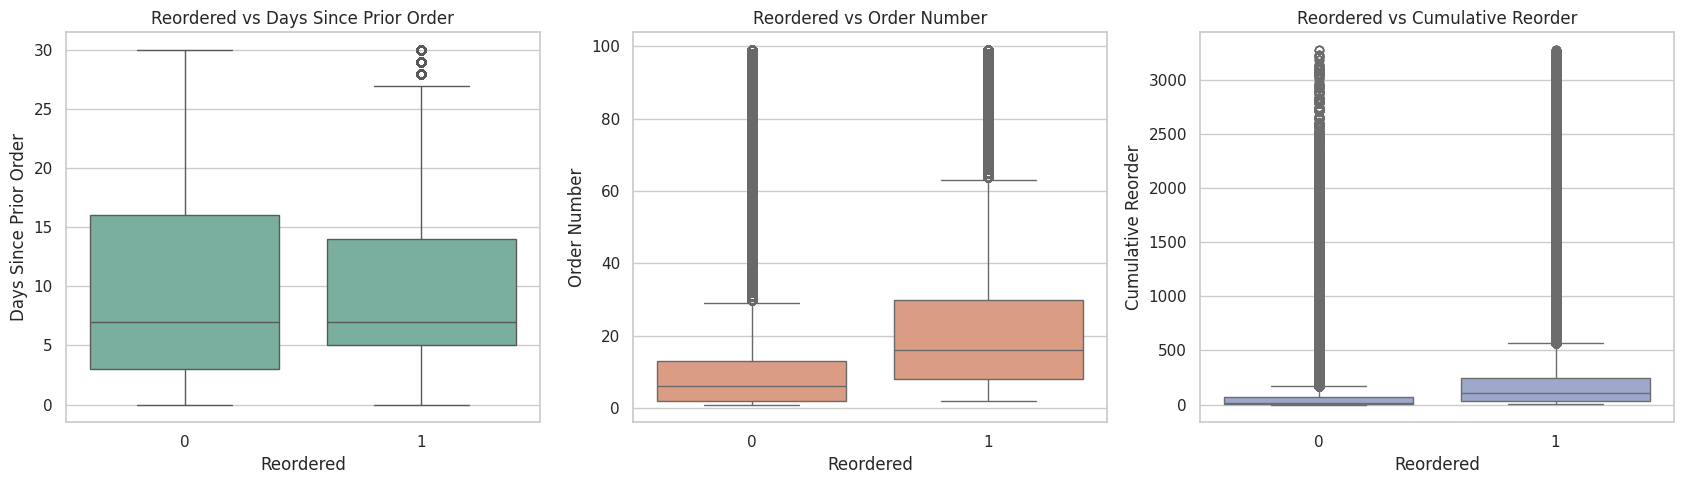

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(x="reordered", y="days_since_prior_order", data=df, ax=axes[0], color="#72B6A1")
axes[0].set_title("Reordered vs Days Since Prior Order")
axes[0].set_xlabel("Reordered")
axes[0].set_ylabel("Days Since Prior Order")

sns.boxplot(x="reordered", y="order_number", data=df, ax=axes[1], color="#E99675")
axes[1].set_title("Reordered vs Order Number")
axes[1].set_xlabel("Reordered")
axes[1].set_ylabel("Order Number")

sns.boxplot(x="reordered", y="cumulative_reorder_per_customer", data=df, ax=axes[2], color="#95A3D3")
axes[2].set_title("Reordered vs Cumulative Reorder")
axes[2].set_xlabel("Reordered")
axes[2].set_ylabel("Cumulative Reorder")

plt.tight_layout()
plt.show()

In [4]:
# Compare metrics between reordered and non-reordered items
reordered_yes = df[df["reordered"] == 1]
reordered_no = df[df["reordered"] == 0]

comparison_stats = {
    "days_since_prior_order": reordered_yes["days_since_prior_order"].mean() - reordered_no["days_since_prior_order"].mean(),
    "order_number": reordered_yes["order_number"].median() - reordered_no["order_number"].median(),
    "cumulative_reorder": reordered_yes["cumulative_reorder_per_customer"].median() - reordered_no["cumulative_reorder_per_customer"].median(),
}

pd.Series(comparison_stats, name="difference").to_frame()

,difference
days_since_prior_order,-0.44353
order_number,10.00000
cumulative_reorder,86.00000


### 🔁 Reorder Behavior Analysis

### 1. ⏱️ Timing (Days Between Orders)

- ลูกค้ามัก **reorder เร็วกว่าหรือใกล้เคียงกับ order ปกติ**
- Median ของ reorder ≈ non-reorder (≈ 7 วัน)

**Insight:**  
การซื้อซ้ำไม่ได้ขึ้นอยู่กับ “ระยะเวลา” เพียงอย่างเดียว แต่สะท้อนถึงพฤติกรรมเชิงนิสัย (habit-driven behavior)

---

### 2. 🔢 Order Progression (Order Number)

- Reorder มีแนวโน้มเกิดใน **order ที่สูงขึ้น**
- ลูกค้าใหม่ → มีโอกาส reorder ต่ำ  
- ลูกค้าเก่า → มีโอกาส reorder สูง

**Insight:**  
Customer loyalty ถูกสร้างขึ้นตามเวลา  
(ยิ่งมีประวัติการซื้อมาก → ยิ่งมีแนวโน้มซื้อซ้ำ)

---

### 3. 🔁 Cumulative Behavior

- Reorder ส่วนใหญ่เกิดในลูกค้าที่มี  
  **cumulative reorder สูงอยู่แล้ว**

**Insight:**  
Reorder ไม่ใช่พฤติกรรมของลูกค้าทั่วไป แต่เป็นลักษณะของ  
**กลุ่ม power users หรือ loyal customers**

---

### 🎯 Final Insight

> **Reorder behavior มีความสัมพันธ์กับ customer maturity มากกว่าปัจจัยด้านเวลา โดยลูกค้าที่มีประวัติการซื้อยาวและมี cumulative reorder สูง มีแนวโน้มที่จะซื้อซ้ำมากกว่า สะท้อนถึงการเกิด loyalty ในระยะยาว**

---

### 💡 Key Takeaway

- ไม่ใช่ลูกค้าทุกคนที่จะ reorder  
- แต่ลูกค้าที่เริ่ม reorder แล้ว มีแนวโน้มจะ **reorder ต่อเนื่อง**

👉 พฤติกรรมนี้สะท้อนลักษณะ:
**"Loyal users become increasingly loyal over time"**

### 2.2 Order & Reorder Pattern by Day/Hour

In [5]:
# =========================
# Display settings for readability
# =========================
pd.options.display.float_format = '{:,.2f}'.format  # numeric display with comma and 2 decimals

# =========================
# Order-level aggregation
# =========================
order_level = (
    df.groupby("order_id")
    .agg(
        order_date=("order_date", "first"),
        order_dow=("order_dow", "first"),
        order_hour_of_day=("order_hour_of_day", "first"),
        total_products=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
        days_since_prior_order=("days_since_prior_order", "first"),
    )
    .reset_index()
)

# =========================
# Date-related columns
# =========================
order_level["order_date"] = pd.to_datetime(order_level["order_date"])
order_level["month_num"] = order_level["order_date"].dt.month
order_level["month_name"] = order_level["order_date"].dt.month_name().str[:3]
order_level["week_of_year"] = order_level["order_date"].dt.isocalendar().week.astype(int)

# =========================
# Weekday labels
# =========================
day_map = {0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"}
order_level["day_name"] = pd.Categorical(
    order_level["order_dow"].map(day_map),
    categories=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    ordered=True,
)

# =========================
# Numeric summary (readable)
# =========================
numeric_summary = order_level[[
    "order_hour_of_day",
    "total_products",
    "reorder_rate",
    "days_since_prior_order",
    "month_num",
    "week_of_year",
]].describe()

# Convert reorder_rate to percentage
numeric_summary["reorder_rate"] = numeric_summary["reorder_rate"] * 100

# Round numeric columns for readability
numeric_summary = numeric_summary.round({
    "order_hour_of_day": 0,
    "total_products": 0,
    "reorder_rate": 2,
    "days_since_prior_order": 0,
    "month_num": 0,
    "week_of_year": 0
})

print("\nOrder-level numeric summary:")
display(numeric_summary)

# =========================
# Categorical summary
# =========================
if SHOW_VERBOSE_TABLES:
    print("\nOrder-level categorical summary:")
    display(order_level[["day_name", "month_name"]].describe(include="all"))

# =========================
# Date summary
# =========================
if SHOW_VERBOSE_TABLES:
    date_summary = pd.DataFrame({
        "count": [order_level["order_date"].notna().sum()],
        "min": [order_level["order_date"].min()],
        "max": [order_level["order_date"].max()],
        "nunique": [order_level["order_date"].nunique()],
    }, index=["order_date"])
    
    # Format count with comma
    date_summary["count"] = date_summary["count"].apply(lambda x: f"{x:,}")
    
    print("\nOrder-level date summary:")
    display(date_summary)

# =========================
# Quality checks
# =========================
print("\nQuality checks:")
print(f"Unique orders: {order_level['order_id'].nunique():,}")
print(f"Date range: {order_level['order_date'].min().date()} to {order_level['order_date'].max().date()}")
print(f"Unique months: {order_level['month_name'].nunique()}")


Order-level numeric summary:


,order_hour_of_day,total_products,reorder_rate,days_since_prior_order,month_num,week_of_year
count,"3,214,874.00","3,214,874.00","321,487,400.00","3,214,874.00","3,214,874.00","3,214,874.00"
mean,13.00,10.00,59.87,10.00,6.00,23.00
std,4.00,8.00,33.80,9.00,3.00,14.00
min,0.00,1.00,0.00,0.00,1.00,1.00
25%,10.00,5.00,33.33,3.00,3.00,12.00
50%,13.00,8.00,66.67,7.00,5.00,20.00
75%,16.00,14.00,90.91,14.00,8.00,32.00
max,23.00,145.00,100.00,30.00,12.00,52.00



Quality checks:
Unique orders: 3,214,874
Date range: 2014-07-01 to 2015-07-01
Unique months: 12


### 📊 Order-Level Behavior Summary

### 1. 🕒 Order Timing (order_hour_of_day)

- Median ≈ 13:00 น. (บ่ายโมง)
- 25% - 75% อยู่ช่วงประมาณ 10:00 – 16:00

**Insight:**  
ลูกค้าส่วนใหญ่สั่งสินค้าในช่วง **กลางวันถึงบ่าย**  
สะท้อนพฤติกรรมการสั่งซื้อในช่วงเวลาทำงานหรือพักกลางวัน

---

### 2. 🛒 Basket Size (total_products)

- Median = 8 ชิ้นต่อออเดอร์  
- Mean ≈ 10 ชิ้น  
- มีบางออเดอร์สูงถึง 145 ชิ้น (outliers)

**Insight:**  
ลูกค้ามีพฤติกรรมการซื้อแบบ **basket-style (ซื้อทีละหลายสินค้า)**  
และมีบางกลุ่มที่ซื้อแบบ **bulk / heavy buyers**

---

### 3. 🔁 Reorder Behavior (reorder_rate)

- Median ≈ 0.67  
- 75% percentile ≈ 0.91

**Insight:**  
ในระดับ order:  
ลูกค้าส่วนใหญ่มีสัดส่วนสินค้าในตะกร้าที่เป็น **สินค้าซ้ำค่อนข้างสูง**

👉 สะท้อนว่า:
- ลูกค้ามี “สินค้าประจำ” อยู่ในแต่ละ order
- แต่ยังมีการผสมสินค้ใหม่ (ไม่ใช่ 100% reorder)

---

### 4. ⏱️ Days Between Orders (days_since_prior_order)

- Median = 7 วัน  
- Mean ≈ 10 วัน  
- Distribution ค่อนข้างกระจาย (std สูง)

**Insight:**  
ลูกค้าส่วนใหญ่กลับมาซื้อซ้ำ **ทุก ~1 สัปดาห์**  
แต่มี variability สูง → บางคนซื้อถี่มาก บางคนห่าง

---

### 5. 📅 Seasonality (month_num / week_of_year)

- Median month ≈ 5 (กลางปี)  
- week_of_year กระจายทั่วปี

**Insight:**  
ไม่เห็น seasonality ที่ชัดเจนมาก  
→ เป็นสินค้าที่มี demand ต่อเนื่องทั้งปี (non-seasonal)

---

### 🎯 Final Insight

> **ลูกค้ามีพฤติกรรมการซื้อแบบประจำ (habit-driven) โดยมักสั่งซื้อเป็นรอบ (~สัปดาห์ละครั้ง) และในแต่ละออเดอร์จะมีทั้งสินค้าซ้ำและสินค้าใหม่ผสมกัน สะท้อนถึงการมี core products ที่ซื้อซ้ำร่วมกับ exploratory behavior**

---

### 💡 Key Takeaways

- ลูกค้าซื้อเป็น “routine” (weekly pattern)
- 1 ออเดอร์ = หลายสินค้า (basket behavior)
- มี “สินค้าประจำ” + “สินค้าลองใหม่” อยู่ร่วมกัน
- ธุรกิจมีลักษณะ **high repeat + low seasonality**

#### 2.2.1 Day-Hour KPI Grid (median-focused view)

In [6]:
day_map = {
    0: "Sun", 1: "Mon", 2: "Tue",
    3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"
}

order_level["day_name"] = order_level["order_dow"].map(day_map)
order_level["day_name"] = pd.Categorical(
    order_level["day_name"],
    categories=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    ordered=True,
    )

# Build full 7x24 grid to make gaps explicit (instead of silently missing slots).
all_day_hour = pd.MultiIndex.from_product(
    [["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"], range(24)],
    names=["day_name", "order_hour_of_day"],
)

customer_kpi = (
    order_level.groupby(["day_name", "order_hour_of_day"], observed=False)
    .agg(
        order_count=("order_id", "nunique"),
        avg_products_per_order=("total_products", "mean"),
        median_products_per_order=("total_products", "median"),
        avg_reorder_rate=("reorder_rate", "mean"),
        median_reorder_rate=("reorder_rate", "median"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        median_days_between_orders=("days_since_prior_order", "median"),
    )
    .reindex(all_day_hour)
    .reset_index()
    .sort_values(["day_name", "order_hour_of_day"])
)

# Fill only count with 0; keep averages/medians as NaN when no orders in that slot.
customer_kpi["order_count"] = customer_kpi["order_count"].fillna(0).astype(int)

# Robust feature view for modeling: prefer median-based metrics.
customer_kpi_model = customer_kpi[[
    "day_name",
    "order_hour_of_day",
    "order_count",
    "median_products_per_order",
    "median_reorder_rate",
    "median_days_between_orders",
]].copy()

# Add model-friendly helper features.
customer_kpi_model["is_empty_slot"] = customer_kpi_model["order_count"].eq(0).astype(int)
customer_kpi_model["day_name_code"] = customer_kpi_model["day_name"].cat.codes

# Impute missing median-based features with global medians (fallback to 0 if all missing).
model_feature_cols = [
    "median_products_per_order",
    "median_reorder_rate",
    "median_days_between_orders",
]
missing_before = customer_kpi_model[model_feature_cols].isna().sum()

for col in model_feature_cols:
    fill_value = customer_kpi_model[col].median()
    if pd.isna(fill_value):
        fill_value = 0.0
    customer_kpi_model[col] = customer_kpi_model[col].fillna(fill_value)

missing_after = customer_kpi_model[model_feature_cols].isna().sum()

show_df(
    customer_kpi["day_name"].value_counts().sort_index().to_frame("rows_per_day"),
    title="Rows per day check (should be 24 each):",
)
show_df(
    customer_kpi_model.groupby("day_name", observed=False).head(1),
    title="Median-based view (recommended for robust analysis/modeling):",
)

if SHOW_VERBOSE_TABLES:
    show_df(missing_before.to_frame("missing_count"), title="Model feature missing values (before imputation):")
    show_df(missing_after.to_frame("missing_count"), title="Model feature missing values (after imputation):")

expected_slots = 7 * 24
actual_slots = len(customer_kpi)
total_orders_from_grid = customer_kpi["order_count"].sum()
total_orders_raw = order_level["order_id"].nunique()

print(f"Slots check: expected={expected_slots}, actual={actual_slots}")
print(f"Order coverage check: grid_sum={total_orders_from_grid:,}, raw_unique_orders={total_orders_raw:,}")

Rows per day check (should be 24 each):


,rows_per_day
day_name,
Sun,24
Mon,24
Tue,24
Wed,24
Thu,24
Fri,24
Sat,24


Median-based view (recommended for robust analysis/modeling):


,day_name,order_hour_of_day,order_count,median_products_per_order,median_reorder_rate,median_days_between_orders,is_empty_slot,day_name_code
0,Sun,0,3692,9.00,0.64,8.00,0,0
24,Mon,0,3475,9.00,0.67,8.00,0,1
48,Tue,0,2906,8.00,0.64,8.00,0,2
72,Wed,0,2767,8.00,0.62,8.00,0,3
96,Thu,0,2476,8.00,0.62,8.00,0,4
120,Fri,0,2989,8.00,0.62,7.00,0,5
144,Sat,0,3067,8.00,0.64,7.00,0,6


Slots check: expected=168, actual=168
Order coverage check: grid_sum=3,214,874, raw_unique_orders=3,214,874


### TOP 10 Days have High Peak OrderCount

In [7]:
customer_kpi.sort_values("order_count", ascending=False).head(10)

,day_name,order_hour_of_day,order_count,avg_products_per_order,median_products_per_order,avg_reorder_rate,median_reorder_rate,avg_days_between_orders,median_days_between_orders
34,Mon,10,52999,10.38,8.00,0.64,0.71,10.11,7.00
14,Sun,14,50484,11.19,10.00,0.58,0.63,10.76,7.00
15,Sun,15,50020,11.04,9.00,0.59,0.64,10.77,7.00
13,Sun,13,49997,11.17,10.00,0.59,0.64,10.78,7.00
33,Mon,9,49533,10.22,8.00,0.66,0.75,9.78,7.00
35,Mon,11,49008,10.40,8.00,0.62,0.67,10.23,7.00
12,Sun,12,47729,11.22,10.00,0.58,0.62,10.76,7.00
11,Sun,11,47357,11.31,10.00,0.59,0.64,10.77,7.00
16,Sun,16,45930,10.92,9.00,0.59,0.63,10.70,7.00
10,Sun,10,44999,11.47,10.00,0.60,0.67,10.70,7.00


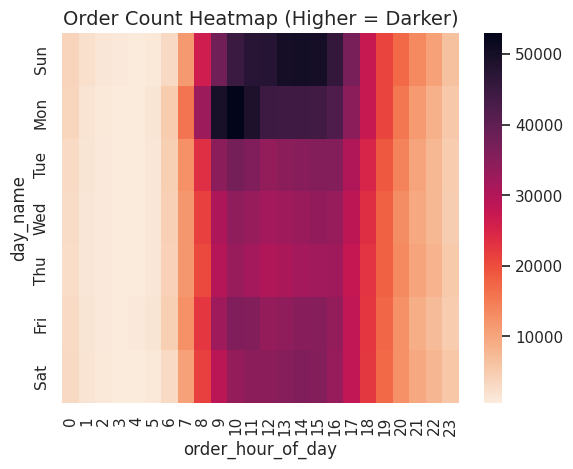

In [8]:
pivot = customer_kpi.pivot(
    index="day_name",
    columns="order_hour_of_day",
    values="order_count",
 )

sns.heatmap(pivot, cmap="rocket_r")
plt.title("Order Count Heatmap (Higher = Darker)", fontsize=14)
plt.show()

In [9]:
order_count_pivot_per_day = customer_kpi.pivot(
    index="day_name",
    columns="order_hour_of_day",
    values="order_count"
)

print(order_count_pivot_per_day)

order_hour_of_day    0     1     2    3    4     5     6      7      8   \
day_name                                                                  
Sun                3692  2235  1299  888  750  1076  3138  11530  26223   
Mon                3475  1735  1063  711  761  1523  5101  15792  32563   
Tue                2906  1485   892  679  700  1330  4524  12550  23488   
Wed                2767  1407   889  605  666  1265  4314  11739  21305   
Thu                2476  1414   837  640  694  1251  4135  11823  20597   
Fri                2989  1539   953  796  857  1466  4573  12590  22623   
Sat                3067  1781  1137  801  747  1061  3007  10632  21522   

order_hour_of_day     9      10     11     12     13     14     15     16  \
day_name                                                                    
Sun                37990  44999  47357  47729  49997  50484  50020  45930   
Mon                49533  52999  49008  44550  44235  44220  43913  42200   
Tue             

### 📊 สรุปพฤติกรรมการสั่งซื้อจาก (Order Count)

1. **ช่วงเวลาที่มีคำสั่งซื้อสูงสุด (Peak Hours)**
   - ประมาณ **8:00 – 17:00**, โดยเฉพาะ **10:00 – 16:00**
   - ลูกค้าส่วนใหญ่สั่งซื้อในช่วงกลางวัน

2. **แนวโน้มตามวันของสัปดาห์**
   - **วันจันทร์ (Mon)** มียอดสูงสุด
   - วันพฤหัส–ศุกร์ สูงรองลงมา
   - วันเสาร์–อาทิตย์ ยอดน้อยกว่า แต่ยังมี peak กลางวัน

3. **ช่วงเวลาที่คำสั่งซื้อน้อยสุด**
   - **0:00 – 6:00** เป็นช่วงที่แทบไม่มีคำสั่งซื้อ

4. **แนวโน้มทั่วไป**
   - รูปแบบคล้าย **ระฆังกลางวัน** (bell-shaped)
   - Peak ของแต่ละวันอยู่กลางวัน ± shift เล็กน้อย

💡 **ข้อเสนอแนะเชิงธุรกิจ**
- ส่งโปรโมชันหรือแจ้งเตือน → ช่วง 10:00 – 16:00
- วางแผนพนักงาน / logistic → เพิ่มกำลังช่วงกลางวัน ลดช่วงกลางคืน
- โมเดล forecast → ใช้ feature `day_name` + `order_hour_of_day` กับ median order_count

### TOP 10 Days have average ReorderRate

In [10]:
customer_kpi.sort_values("median_reorder_rate", ascending=False).head(10)

,day_name,order_hour_of_day,order_count,avg_products_per_order,median_products_per_order,avg_reorder_rate,median_reorder_rate,avg_days_between_orders,median_days_between_orders
30,Mon,6,5101,10.35,8.00,0.66,0.75,9.82,7.00
31,Mon,7,15792,10.48,9.00,0.68,0.75,9.82,7.00
33,Mon,9,49533,10.22,8.00,0.66,0.75,9.78,7.00
32,Mon,8,32563,10.24,8.00,0.67,0.75,9.74,7.00
54,Tue,6,4524,9.69,8.00,0.65,0.74,10.04,7.00
55,Tue,7,12550,9.76,8.00,0.65,0.73,9.86,7.00
79,Wed,7,11739,9.43,8.00,0.65,0.73,9.57,7.00
7,Sun,7,11530,11.57,10.00,0.64,0.71,10.19,7.00
151,Sat,7,10632,11.06,9.00,0.64,0.71,9.90,7.00
78,Wed,6,4314,9.49,8.00,0.64,0.71,9.61,7.00


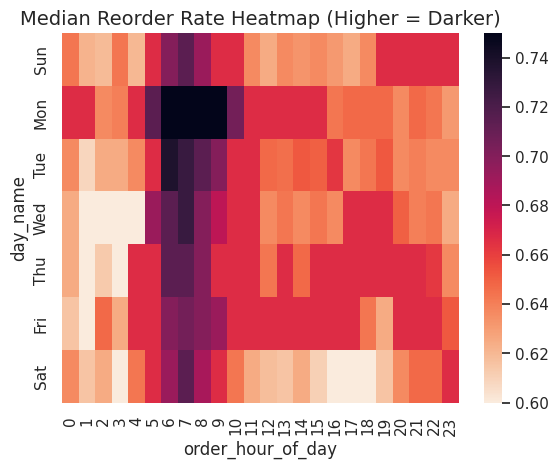

In [11]:
pivot = customer_kpi.pivot(
    index="day_name",
    columns="order_hour_of_day",
    values="median_reorder_rate"
 )

sns.heatmap(pivot, cmap="rocket_r")
plt.title("Median Reorder Rate Heatmap (Higher = Darker)", fontsize=14)
plt.show()

In [12]:
reorder_rate_pivot_per_day = customer_kpi.pivot(
    index="day_name",
    columns="order_hour_of_day",
    values="median_reorder_rate"
)

print(reorder_rate_pivot_per_day)

order_hour_of_day   0    1    2    3    4    5    6    7    8    9    10   11  \
day_name                                                                        
Sun               0.64 0.62 0.62 0.64 0.62 0.67 0.70 0.71 0.69 0.67 0.67 0.64   
Mon               0.67 0.67 0.64 0.64 0.67 0.71 0.75 0.75 0.75 0.75 0.71 0.67   
Tue               0.64 0.61 0.62 0.62 0.64 0.67 0.74 0.73 0.71 0.70 0.67 0.67   
Wed               0.62 0.60 0.60 0.60 0.60 0.69 0.71 0.73 0.70 0.68 0.67 0.67   
Thu               0.62 0.60 0.61 0.60 0.67 0.67 0.71 0.71 0.70 0.67 0.67 0.67   
Fri               0.62 0.60 0.65 0.62 0.67 0.67 0.70 0.71 0.70 0.69 0.67 0.67   
Sat               0.64 0.62 0.62 0.60 0.64 0.67 0.69 0.71 0.69 0.67 0.64 0.62   

order_hour_of_day   12   13   14   15   16   17   18   19   20   21   22   23  
day_name                                                                       
Sun               0.62 0.64 0.63 0.64 0.63 0.62 0.64 0.67 0.67 0.67 0.67 0.67  
Mon               0.67 0.67 0.

<Axes: xlabel='order_hour_of_day', ylabel='median_reorder_rate'>

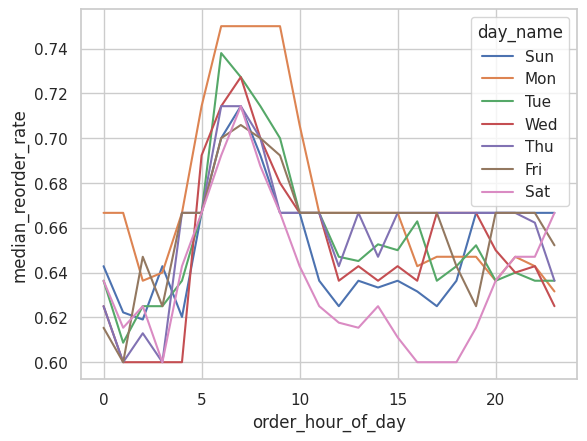

In [13]:
sns.lineplot(
    data=customer_kpi,
    x="order_hour_of_day",
    y="median_reorder_rate",
    hue="day_name"
    )

### 📊 Median Reorder Rate by Hour & Day — Key Insights

### 🔥 1. Early Morning Peak (06:00–08:00)
- ช่วงเวลา **06:00–08:00 น.** มีค่า reorder rate สูงที่สุด (~0.74–0.75)
- เห็นได้ชัดในหลายวัน โดยเฉพาะ **วันจันทร์ (Monday)**
- แสดงถึงพฤติกรรม **routine purchasing / restocking**

> 📌 Insight: ผู้ใช้ช่วงเช้ามีแนวโน้มเป็นลูกค้าประจำ (high loyalty)

---

### 📅 2. Monday Shows Strongest Reorder Behavior
- วันจันทร์มี peak สูงสุดของทั้ง dataset
- ค่า reorder สูงต่อเนื่องในช่วงเช้า

> 📌 Insight: เป็นพฤติกรรม “start-of-week restocking”

---

### 📉 3. Midday Drop (10:00–17:00)
- ช่วงสายถึงบ่าย ค่า reorder ลดลง (~0.60–0.66)
- พบ pattern นี้แทบทุกวัน

> 📌 Insight: ลูกค้ามีแนวโน้ม “explore สินค้าใหม่” มากกว่าซื้อซ้ำ

---

### 🌙 4. Evening Recovery (18:00–23:00)
- ค่า reorder กลับมาอยู่ระดับปานกลาง (~0.63–0.67)
- ไม่สูงเท่าช่วงเช้า แต่ไม่ต่ำสุด

> 📌 Insight: มีการซื้อซ้ำบ้าง แต่ไม่ใช่ช่วง peak ของ loyalty

---

### 📊 5. Clear Behavioral Pattern (Not Flat)
- ค่า reorder rate ไม่ได้คงที่ทั้งวัน
- มีความแตกต่างชัดเจนระหว่าง:
  - ช่วง peak (~0.75)
  - ช่วงต่ำ (~0.60)

> 📌 Insight: Time-of-day มีผลต่อพฤติกรรมลูกค้าอย่างมีนัยสำคัญ

---

### 📆 6. Weekday vs Weekend Behavior
- วันธรรมดา (Mon–Fri): มี pattern ชัดเจน โดยเฉพาะช่วงเช้า
- วันหยุด (Sat–Sun): ค่า reorder ต่ำกว่าเล็กน้อย และกระจายมากกว่า

> 📌 Insight: Weekend มีแนวโน้มเป็น exploratory behavior มากขึ้น

---

### 🧠 Overall Conclusion
- **Morning users = High loyalty (reorder สูง)**
- **Midday users = Exploration mode**
- **Monday = Key restocking day**
- พฤติกรรมลูกค้าเปลี่ยนตามช่วงเวลาอย่างชัดเจน

---

### 🎯 Business Implications
- 📌 Promote "reorder / subscription" → ช่วงเช้า
- 📌 Promote "new products / discovery" → ช่วงบ่าย
- 📌 Target campaigns → วันจันทร์ (high intent users)

<Axes: xlabel='day_name', ylabel='reorder_rate'>

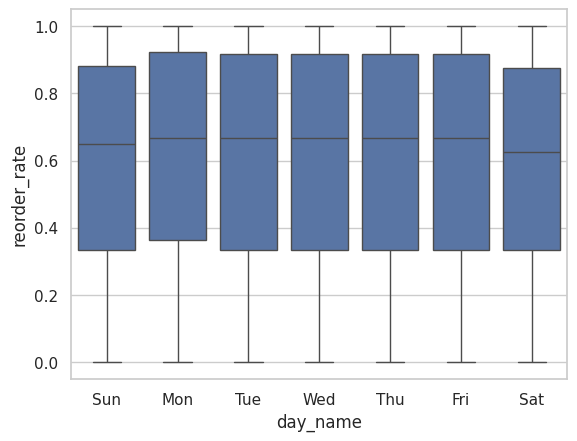

In [15]:
sns.boxplot(
    data=order_level,
    x="day_name",
    y="reorder_rate"
    )

OOO

## 5) Basket Value & Repeat Rate by Category

Category summary (department) - top 12 by order lines:


,department,order_lines,unique_orders,unique_users,repeat_rate,avg_line_value,median_line_value,avg_category_basket_value,median_category_basket_value,p90_category_basket_value
0,produce,9479291,2409320,193237,0.65,1.00,1.00,3.93,3.00,8.00
1,dairy eggs,5414016,2177338,190565,0.67,1.00,1.00,2.49,2.00,5.00
2,snacks,2887550,1391447,174219,0.57,1.00,1.00,2.08,1.00,4.00
3,beverages,2690129,1457351,172795,0.65,1.00,1.00,1.85,1.00,3.00
4,frozen,2236432,1181018,163233,0.54,1.00,1.00,1.89,1.00,4.00
5,pantry,1875577,1117892,172755,0.35,1.00,1.00,1.68,1.00,3.00
6,bakery,1176787,881556,140612,0.63,1.00,1.00,1.33,1.00,2.00
7,canned goods,1068058,681305,133733,0.46,1.00,1.00,1.57,1.00,3.00
8,deli,1051249,770300,133865,0.61,1.00,1.00,1.36,1.00,2.00
9,dry goods pasta,866627,597862,124820,0.46,1.00,1.00,1.45,1.00,2.00


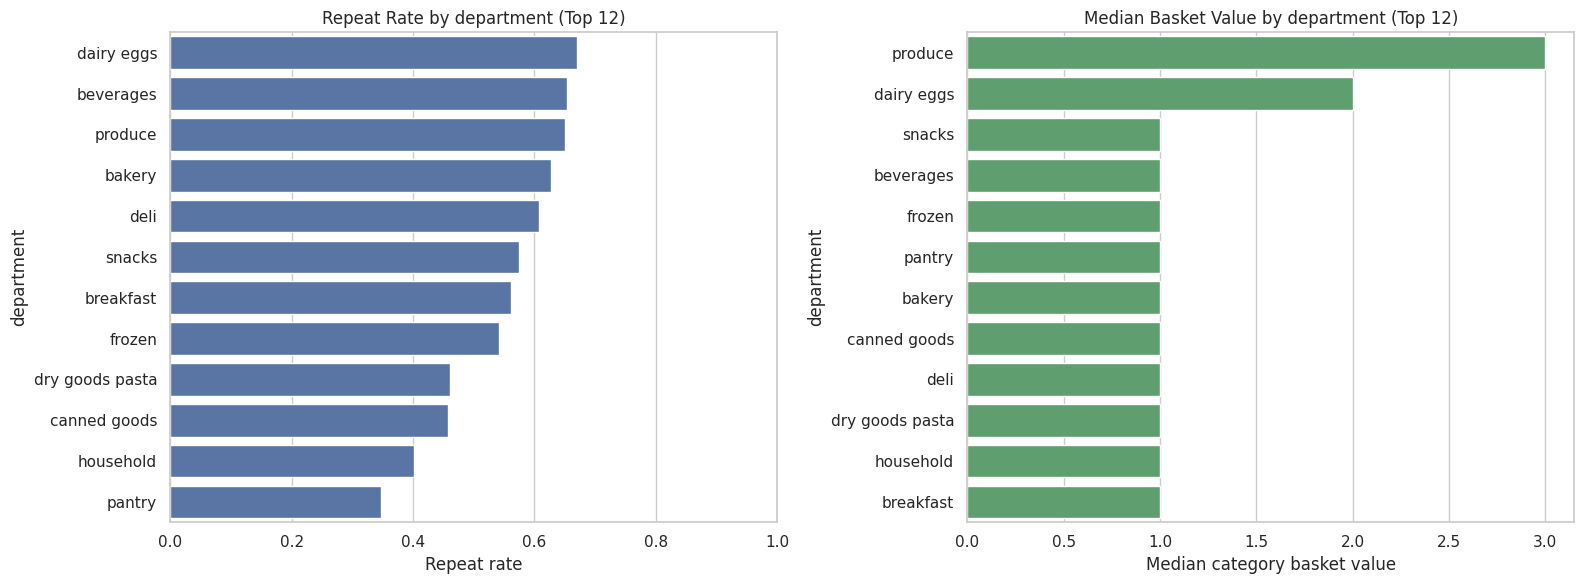

In [23]:
# --- Basket value / Repeat rate by product category ---
CATEGORY_COL = "department"  # switch to "aisle" for finer granularity
TOP_N_CATEGORY = 12

category_df = df.copy()

# Ensure category column exists.
if CATEGORY_COL not in category_df.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", CATEGORY_COL]]
    category_df = category_df.merge(product_dim, on="product_id", how="left")

category_df[CATEGORY_COL] = category_df[CATEGORY_COL].fillna("Unknown")

# 1) Line-level metrics: repeat behavior + value per line by category
category_line_metrics = (
    category_df.groupby(CATEGORY_COL, observed=False)
    .agg(
        order_lines=("product_id", "count"),
        unique_orders=("order_id", "nunique"),
        unique_users=("user_id", "nunique"),
        repeat_rate=("reordered", "mean"),
        avg_line_value=("total_price", "mean"),
        median_line_value=("total_price", "median"),
    )
    .reset_index()
    .sort_values(["order_lines", CATEGORY_COL], ascending=[False, True])
)

# 2) Order-category basket metrics: spend per order within each category
order_category_value = (
    category_df.groupby(["order_id", CATEGORY_COL], observed=False)
    .agg(category_basket_value=("total_price", "sum"))
    .reset_index()
)

category_basket_metrics = (
    order_category_value.groupby(CATEGORY_COL, observed=False)
    .agg(
        avg_category_basket_value=("category_basket_value", "mean"),
        median_category_basket_value=("category_basket_value", "median"),
        p90_category_basket_value=("category_basket_value", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

category_summary = (
    category_line_metrics.merge(category_basket_metrics, on=CATEGORY_COL, how="left")
    .sort_values(["order_lines", CATEGORY_COL], ascending=[False, True])
    .reset_index(drop=True)
)

top_categories = category_summary.head(TOP_N_CATEGORY).copy()

show_df(top_categories, title=f"Category summary ({CATEGORY_COL}) - top {TOP_N_CATEGORY} by order lines:")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_categories.sort_values("repeat_rate", ascending=False),
    x="repeat_rate",
    y=CATEGORY_COL,
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title(f"Repeat Rate by {CATEGORY_COL} (Top {TOP_N_CATEGORY})")
axes[0].set_xlabel("Repeat rate")
axes[0].set_ylabel(CATEGORY_COL)
axes[0].set_xlim(0, 1)

sns.barplot(
    data=top_categories.sort_values("median_category_basket_value", ascending=False),
    x="median_category_basket_value",
    y=CATEGORY_COL,
    color="#55A868",
    ax=axes[1],
)
axes[1].set_title(f"Median Basket Value by {CATEGORY_COL} (Top {TOP_N_CATEGORY})")
axes[1].set_xlabel("Median category basket value")
axes[1].set_ylabel(CATEGORY_COL)

plt.tight_layout()
plt.show()

if SHOW_VERBOSE_TABLES:
    show_df(
        category_summary[[
            CATEGORY_COL,
            "order_lines",
            "repeat_rate",
            "avg_line_value",
            "median_line_value",
            "avg_category_basket_value",
            "median_category_basket_value",
            "p90_category_basket_value",
        ]].describe(include="all"),
        title="Category metrics describe:",
    )

## 6) Customer Lifetime Value (CLV)

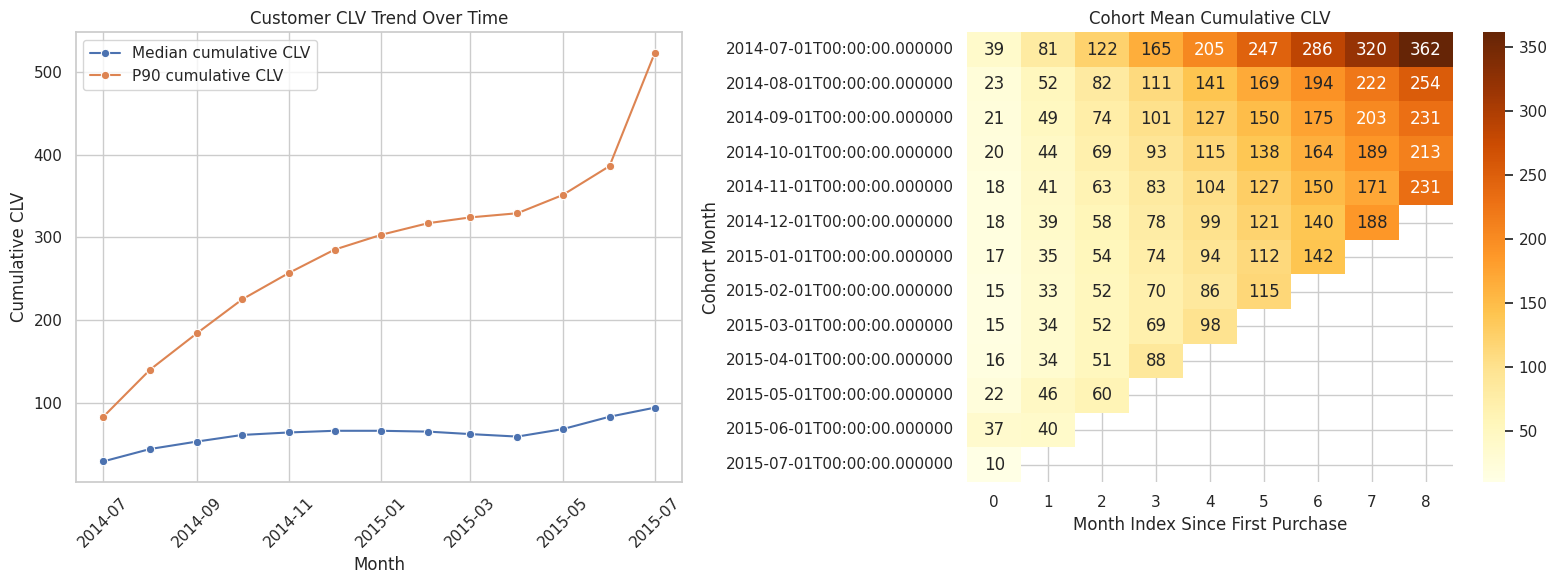

Customer CLV profile summary:


,total_orders,total_spend,avg_order_value,lifetime_days,orders_per_month,estimated_monthly_clv
count,"206,209.00","206,209.00","206,209.00","206,209.00","206,209.00","206,209.00"
mean,15.59,157.29,9.95,157.22,2.83,27.98
std,16.65,204.21,5.86,103.19,1.71,23.80
min,3.00,3.00,1.00,1.00,1.11,1.15
25%,5.00,39.00,5.74,67.00,1.75,12.86
50%,9.00,83.00,8.93,133.00,2.36,21.92
75%,19.00,188.00,13.00,238.00,3.31,35.91
max,99.00,"3,725.00",70.25,366.00,99.00,"1,369.29"


Latest CLV trend snapshot:


,order_month,active_customers,avg_monthly_spend,median_cumulative_clv,p90_cumulative_clv
7,2015-02-01,120843,22.03,65.00,317.00
8,2015-03-01,148737,23.81,62.00,324.00
9,2015-04-01,181852,23.88,59.00,329.00
10,2015-05-01,201055,24.22,68.00,351.00
11,2015-06-01,206203,22.57,83.00,386.00
12,2015-07-01,3319,9.67,94.00,523.00


In [24]:
# --- Customer Lifetime Value (CLV) trends ---
CLV_FREQ = "M"  # monthly trend
MAX_MONTH_INDEX = 8  # keep cohort chart readable

if "total_price" not in df.columns:
    raise ValueError("`total_price` column is required for CLV analysis.")

# Build order-level value first to avoid line-level double counting in CLV.
order_value = (
    df.groupby(["user_id", "order_id", "order_date"], observed=False)
    .agg(order_value=("total_price", "sum"))
    .reset_index()
)
order_value["order_month"] = order_value["order_date"].dt.to_period(CLV_FREQ).dt.to_timestamp()

# 1) Customer-level CLV profile
customer_clv = (
    order_value.groupby("user_id", observed=False)
    .agg(
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max"),
        total_orders=("order_id", "nunique"),
        total_spend=("order_value", "sum"),
        avg_order_value=("order_value", "mean"),
    )
    .reset_index()
)

customer_clv["lifetime_days"] = (
    customer_clv["last_order_date"] - customer_clv["first_order_date"]
).dt.days + 1
customer_clv["lifetime_months"] = np.maximum(customer_clv["lifetime_days"] / 30.0, 1)
customer_clv["orders_per_month"] = customer_clv["total_orders"] / customer_clv["lifetime_months"]
customer_clv["estimated_monthly_clv"] = customer_clv["avg_order_value"] * customer_clv["orders_per_month"]

# 2) Monthly trend of cumulative CLV per customer
customer_monthly = (
    order_value.groupby(["user_id", "order_month"], observed=False)
    .agg(monthly_spend=("order_value", "sum"))
    .reset_index()
    .sort_values(["user_id", "order_month"])
)
customer_monthly["cumulative_clv"] = customer_monthly.groupby("user_id", observed=False)["monthly_spend"].cumsum()

clv_trend = (
    customer_monthly.groupby("order_month", observed=False)
    .agg(
        active_customers=("user_id", "nunique"),
        avg_monthly_spend=("monthly_spend", "mean"),
        median_cumulative_clv=("cumulative_clv", "median"),
        p90_cumulative_clv=("cumulative_clv", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

# 3) Cohort CLV progression (by first purchase month)
cohort_base = order_value[["user_id", "order_month"]].drop_duplicates().copy()
cohort_base["cohort_month"] = cohort_base.groupby("user_id", observed=False)["order_month"].transform("min")
cohort_base["month_index"] = (
    cohort_base["order_month"].dt.to_period(CLV_FREQ).astype(int)
    - cohort_base["cohort_month"].dt.to_period(CLV_FREQ).astype(int)
)

cohort_clv = customer_monthly.merge(
    cohort_base[["user_id", "order_month", "cohort_month", "month_index"]],
    on=["user_id", "order_month"],
    how="left",
)

cohort_clv_progress = (
    cohort_clv[cohort_clv["month_index"] <= MAX_MONTH_INDEX]
    .groupby(["cohort_month", "month_index"], observed=False)
    .agg(
        customers=("user_id", "nunique"),
        mean_cumulative_clv=("cumulative_clv", "mean"),
        median_cumulative_clv=("cumulative_clv", "median"),
    )
    .reset_index()
)

cohort_clv_pivot = cohort_clv_progress.pivot(
    index="cohort_month",
    columns="month_index",
    values="mean_cumulative_clv",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=clv_trend,
    x="order_month",
    y="median_cumulative_clv",
    marker="o",
    label="Median cumulative CLV",
    ax=axes[0],
)
sns.lineplot(
    data=clv_trend,
    x="order_month",
    y="p90_cumulative_clv",
    marker="o",
    label="P90 cumulative CLV",
    ax=axes[0],
)
axes[0].set_title("Customer CLV Trend Over Time")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Cumulative CLV")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(cohort_clv_pivot, annot=True, fmt=".0f", cmap="YlOrBr", ax=axes[1])
axes[1].set_title("Cohort Mean Cumulative CLV")
axes[1].set_xlabel("Month Index Since First Purchase")
axes[1].set_ylabel("Cohort Month")

plt.tight_layout()
plt.show()

show_df(
    customer_clv[[
        "total_orders",
        "total_spend",
        "avg_order_value",
        "lifetime_days",
        "orders_per_month",
        "estimated_monthly_clv",
    ]].describe(),
    title="Customer CLV profile summary:",
)
show_df(clv_trend.tail(6), title="Latest CLV trend snapshot:")

if SHOW_VERBOSE_TABLES:
    show_df(cohort_clv_progress.head(20), title="Cohort CLV progression sample:")

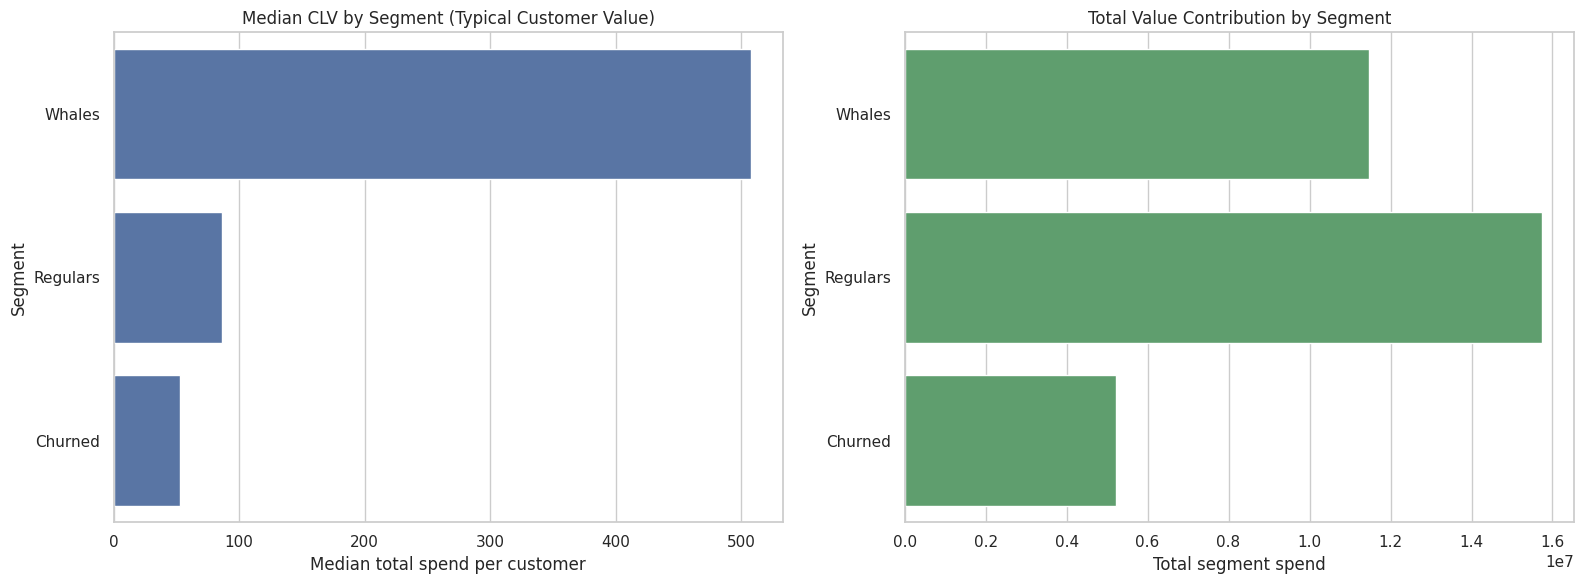

Segment CLV summary:


,segment,customers,median_total_spend,mean_total_spend,median_avg_order_value,median_orders_per_month,median_estimated_monthly_clv,total_segment_spend,segment_share_of_spend,median_latest_cumulative_clv
0,Whales,20024,508.00,572.93,9.34,4.69,47.24,11472267,0.35,508.00
1,Regulars,122999,86.00,128.00,9.03,2.42,22.27,15743925,0.49,86.00
2,Churned,63186,53.00,82.59,8.50,1.90,17.06,5218297,0.16,53.00


Top segment by median customer value: Whales (median_total_spend=508.00)
Top segment by total business contribution: Regulars (total_segment_spend=15,743,925.00, share=48.54%)


In [25]:
# --- CLV by segment (median-focused) ---
# Why median: robust to extreme spenders and better reflects a "typical" customer in each segment.

if "segment" not in rfm.columns:
    raise ValueError("`rfm` with `segment` column is required for segment-level CLV analysis.")

# Join customer CLV profile with existing RFM segment labels.
segment_clv_base = customer_clv.merge(
    rfm[["user_id", "segment"]],
    on="user_id",
    how="left",
)
segment_clv_base["segment"] = segment_clv_base["segment"].fillna("Unknown")

segment_clv_summary = (
    segment_clv_base.groupby("segment", observed=False)
    .agg(
        customers=("user_id", "nunique"),
        median_total_spend=("total_spend", "median"),
        mean_total_spend=("total_spend", "mean"),
        median_avg_order_value=("avg_order_value", "median"),
        median_orders_per_month=("orders_per_month", "median"),
        median_estimated_monthly_clv=("estimated_monthly_clv", "median"),
        total_segment_spend=("total_spend", "sum"),
    )
    .reset_index()
)

segment_clv_summary["segment_share_of_spend"] = (
    segment_clv_summary["total_segment_spend"]
    / segment_clv_summary["total_segment_spend"].sum()
)

segment_clv_summary = segment_clv_summary.sort_values(
    ["median_total_spend", "total_segment_spend"],
    ascending=[False, False],
).reset_index(drop=True)

# Latest cumulative CLV per customer (for an alternative median view).
latest_customer_clv = (
    customer_monthly.sort_values(["user_id", "order_month"])
    .groupby("user_id", observed=False)
    .tail(1)[["user_id", "cumulative_clv"]]
)

segment_latest_median = (
    latest_customer_clv.merge(rfm[["user_id", "segment"]], on="user_id", how="left")
    .groupby("segment", observed=False)
    .agg(median_latest_cumulative_clv=("cumulative_clv", "median"))
    .reset_index()
)

segment_clv_summary = segment_clv_summary.merge(
    segment_latest_median,
    on="segment",
    how="left",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=segment_clv_summary.sort_values("median_total_spend", ascending=False),
    x="median_total_spend",
    y="segment",
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title("Median CLV by Segment (Typical Customer Value)")
axes[0].set_xlabel("Median total spend per customer")
axes[0].set_ylabel("Segment")

sns.barplot(
    data=segment_clv_summary.sort_values("total_segment_spend", ascending=False),
    x="total_segment_spend",
    y="segment",
    color="#55A868",
    ax=axes[1],
)
axes[1].set_title("Total Value Contribution by Segment")
axes[1].set_xlabel("Total segment spend")
axes[1].set_ylabel("Segment")

plt.tight_layout()
plt.show()

show_df(segment_clv_summary, title="Segment CLV summary:")

top_median_segment = segment_clv_summary.iloc[0]
top_total_segment = segment_clv_summary.sort_values("total_segment_spend", ascending=False).iloc[0]

print(
    f"Top segment by median customer value: {top_median_segment['segment']} "
    f"(median_total_spend={top_median_segment['median_total_spend']:,.2f})"
)
print(
    f"Top segment by total business contribution: {top_total_segment['segment']} "
    f"(total_segment_spend={top_total_segment['total_segment_spend']:,.2f}, "
    f"share={top_total_segment['segment_share_of_spend']:.2%})"
)

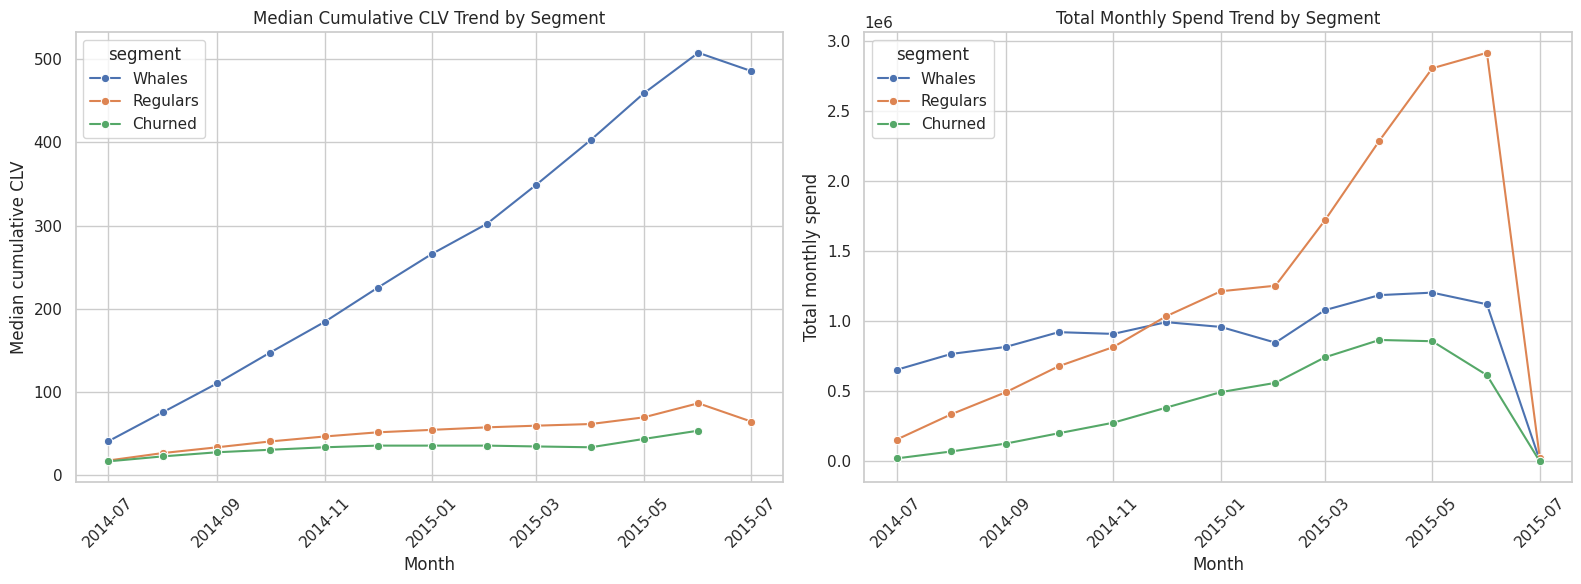

Segment CLV monthly trend snapshot:


,order_month,segment,active_customers,total_monthly_spend,median_monthly_spend,median_cumulative_clv
27,2015-04-01,Whales,20013,1187047,51.00,403.00
28,2015-04-01,Regulars,101841,2289614,16.00,61.00
29,2015-04-01,Churned,59998,866820,10.00,33.00
30,2015-05-01,Whales,20021,1204765,51.00,459.00
31,2015-05-01,Regulars,117853,2806462,17.00,69.00
32,2015-05-01,Churned,63181,857900,10.00,43.00
33,2015-06-01,Whales,20024,1121555,46.00,508.00
34,2015-06-01,Regulars,122993,2917157,17.00,86.00
35,2015-06-01,Churned,63186,615618,8.00,53.00
36,2015-07-01,Whales,690,6916,7.00,486.00


Pairwise median CLV comparison:


,segment_a,segment_b,n_a,n_b,median_a,median_b,median_diff_a_minus_b,p_value,q_value_bh,significant_5pct
0,Churned,Regulars,63186,122999,53.00,86.00,-33.00,0.00,0.00,True
1,Churned,Whales,63186,20024,53.00,508.00,-455.00,0.00,0.00,True
2,Regulars,Whales,122999,20024,86.00,508.00,-422.00,0.00,0.00,True


In [26]:
# --- Segment CLV trend over time + median significance checks ---
SEGMENT_CLV_TEST_PERMUTATIONS = 2000
RANDOM_SEED = 42

segment_monthly = customer_monthly.merge(
    rfm[["user_id", "segment"]],
    on="user_id",
    how="left",
)
segment_monthly["segment"] = segment_monthly["segment"].fillna("Unknown")

segment_clv_trend = (
    segment_monthly.groupby(["order_month", "segment"], observed=False)
    .agg(
        active_customers=("user_id", "nunique"),
        total_monthly_spend=("monthly_spend", "sum"),
        median_monthly_spend=("monthly_spend", "median"),
        median_cumulative_clv=("cumulative_clv", "median"),
    )
    .reset_index()
    .sort_values(["order_month", "segment"])
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=segment_clv_trend,
    x="order_month",
    y="median_cumulative_clv",
    hue="segment",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Median Cumulative CLV Trend by Segment")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Median cumulative CLV")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=segment_clv_trend,
    x="order_month",
    y="total_monthly_spend",
    hue="segment",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Total Monthly Spend Trend by Segment")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total monthly spend")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

show_df(segment_clv_trend.tail(12), title="Segment CLV monthly trend snapshot:")


def permutation_test_median_diff(a, b, n_permutations=2000, seed=42):
    """Two-sided permutation test for median difference."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan

    observed = np.median(a) - np.median(b)
    combined = np.concatenate([a, b])
    n_a = len(a)

    rng = np.random.default_rng(seed)
    extreme = 0
    for _ in range(n_permutations):
        permuted = rng.permutation(combined)
        diff = np.median(permuted[:n_a]) - np.median(permuted[n_a:])
        if abs(diff) >= abs(observed):
            extreme += 1

    p_value = (extreme + 1) / (n_permutations + 1)
    return observed, p_value


def benjamini_hochberg(p_values):
    """Return BH-adjusted q-values in original order."""
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked_p = p[order]

    q = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked_p[i] * n / rank
        prev = min(prev, val)
        q[i] = prev

    q = np.clip(q, 0, 1)
    q_original_order = np.empty(n, dtype=float)
    q_original_order[order] = q
    return q_original_order


segment_spend_for_test = segment_clv_base[["segment", "total_spend"]].dropna().copy()
segments = sorted(segment_spend_for_test["segment"].unique())

pairwise_results = []
for i in range(len(segments)):
    for j in range(i + 1, len(segments)):
        seg_a = segments[i]
        seg_b = segments[j]

        spend_a = segment_spend_for_test.loc[
            segment_spend_for_test["segment"] == seg_a,
            "total_spend",
        ]
        spend_b = segment_spend_for_test.loc[
            segment_spend_for_test["segment"] == seg_b,
            "total_spend",
        ]

        median_diff, p_value = permutation_test_median_diff(
            spend_a,
            spend_b,
            n_permutations=SEGMENT_CLV_TEST_PERMUTATIONS,
            seed=RANDOM_SEED,
        )

        pairwise_results.append(
            {
                "segment_a": seg_a,
                "segment_b": seg_b,
                "n_a": int(spend_a.shape[0]),
                "n_b": int(spend_b.shape[0]),
                "median_a": float(np.median(spend_a)),
                "median_b": float(np.median(spend_b)),
                "median_diff_a_minus_b": float(median_diff),
                "p_value": float(p_value),
            }
        )

pairwise_median_test = pd.DataFrame(pairwise_results).sort_values("p_value").reset_index(drop=True)
pairwise_median_test["q_value_bh"] = benjamini_hochberg(pairwise_median_test["p_value"].values)
pairwise_median_test["significant_5pct"] = pairwise_median_test["q_value_bh"] < 0.05

show_df(pairwise_median_test, title="Pairwise median CLV comparison:")

### 6.1 Days Between Orders Distribution by Segment

วิเคราะห์ cadence ของแต่ละ segment ด้วย `days_since_prior_order` แบบ customer-median เพื่อลด noise จาก order รายครั้ง

- Distribution plot: เปรียบเทียบ density ในภาพเดียว
- Box plot: ดู median / IQR / spread ต่อกลุ่ม
- Summary table: customers, median, mean, std, p25, p75

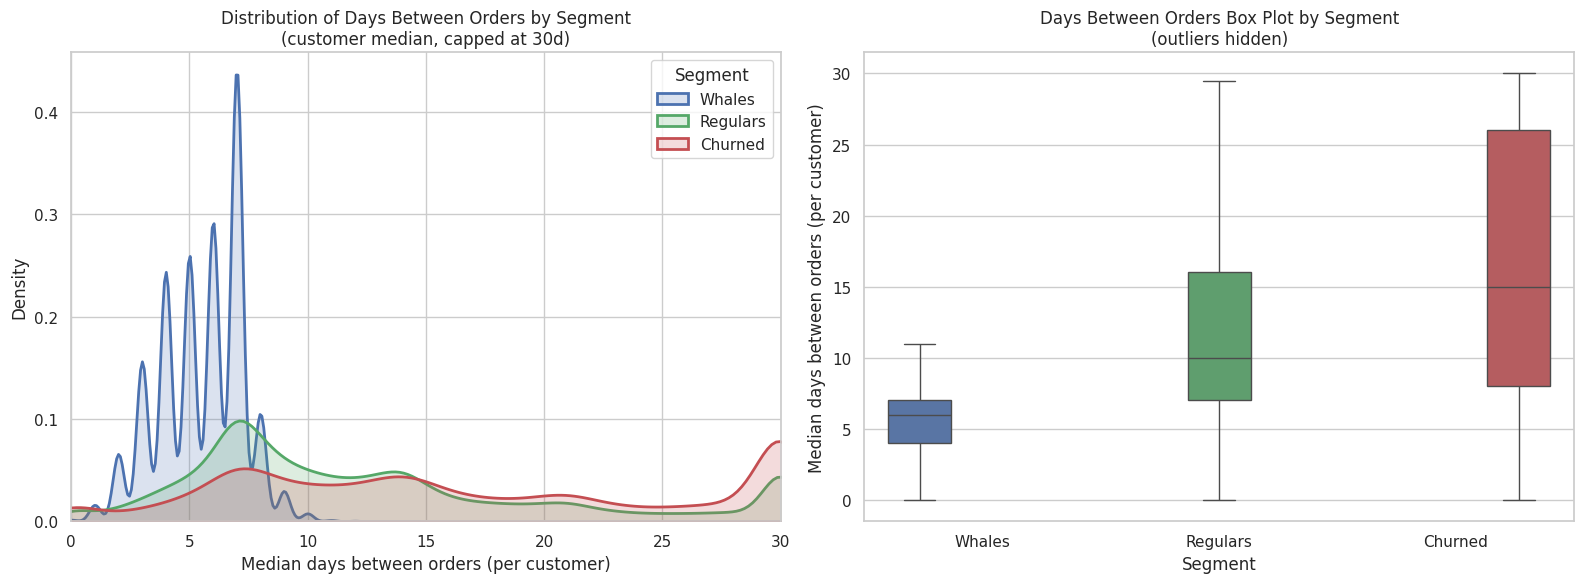

Days between orders summary by segment:


,segment,customers,median,mean,std,p25,p75
0,Whales,20024,6.00,5.52,1.77,4.00,7.00
1,Regulars,122999,10.00,12.58,7.88,7.00,16.00
2,Churned,63186,15.00,16.46,9.28,8.00,26.00



กลุ่มที่สั่งซื้อถี่ที่สุด: Whales (median = 6.0 วัน, IQR = 4.0–7.0)


In [27]:
# --- Days between orders distribution per segment ---
# Use customer-level median to represent each customer's "typical" gap.
# This avoids noise from the first order (NaN days) and large purchase streaks.

days_df = (
    df[df["days_since_prior_order"].notna()]
    .groupby("user_id", observed=False)
    .agg(customer_median_days=("days_since_prior_order", "median"))
    .reset_index()
    .merge(rfm[["user_id", "segment"]], on="user_id", how="left")
)
days_df["segment"] = days_df["segment"].fillna("Unknown")

DAYS_CAP = 30  # cap at 30 for readability; 30d = monthly cadence max
days_plot = days_df.copy()
days_plot["customer_median_days"] = days_plot["customer_median_days"].clip(upper=DAYS_CAP)

SEGMENT_ORDER = ["Whales", "Regulars", "Churned"]
PALETTE = {"Whales": "#4C72B0", "Regulars": "#55A868", "Churned": "#C44E52"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KDE distribution via seaborn (no scipy needed)
for seg in SEGMENT_ORDER:
    grp = days_plot[days_plot["segment"] == seg]["customer_median_days"]
    if len(grp) > 1:
        sns.kdeplot(grp, ax=axes[0], label=seg, linewidth=2, color=PALETTE[seg], fill=True, alpha=0.2)

axes[0].set_title("Distribution of Days Between Orders by Segment\n(customer median, capped at 30d)")
axes[0].set_xlabel("Median days between orders (per customer)")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, DAYS_CAP)
axes[0].legend(title="Segment")

# Box plot — median + spread (outliers hidden for readability)
sns.boxplot(
    data=days_df,
    x="segment",
    y="customer_median_days",
    hue="segment",
    order=SEGMENT_ORDER,
    hue_order=SEGMENT_ORDER,
    palette=PALETTE,
    ax=axes[1],
    showfliers=False,
    legend=False,
)
axes[1].set_title("Days Between Orders Box Plot by Segment\n(outliers hidden)")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Median days between orders (per customer)")

plt.tight_layout()
plt.show()

# Summary table
days_summary = (
    days_df.groupby("segment", observed=False)["customer_median_days"]
    .agg(
        customers="count",
        median="median",
        mean="mean",
        std="std",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
    )
    .reset_index()
    .sort_values("median")
    .reset_index(drop=True)
)

show_df(days_summary, title="Days between orders summary by segment:")

top_freq = days_summary.iloc[0]
print(
    f"\nกลุ่มที่สั่งซื้อถี่ที่สุด: {top_freq['segment']} "
    f"(median = {top_freq['median']:.1f} วัน, IQR = {top_freq['p25']:.1f}–{top_freq['p75']:.1f})"
)

### 6.2 Order Funnel (% Customers Reaching Each Order)

วิเคราะห์ drop-off ของลูกค้าตามจำนวน order สะสม

- Funnel bar chart: % ลูกค้าที่มีอย่างน้อย N orders
- Drop-off rate: % ที่หายไประหว่างแต่ละขั้น
- Segment funnel: เปรียบเทียบ Whales / Regulars / Churned

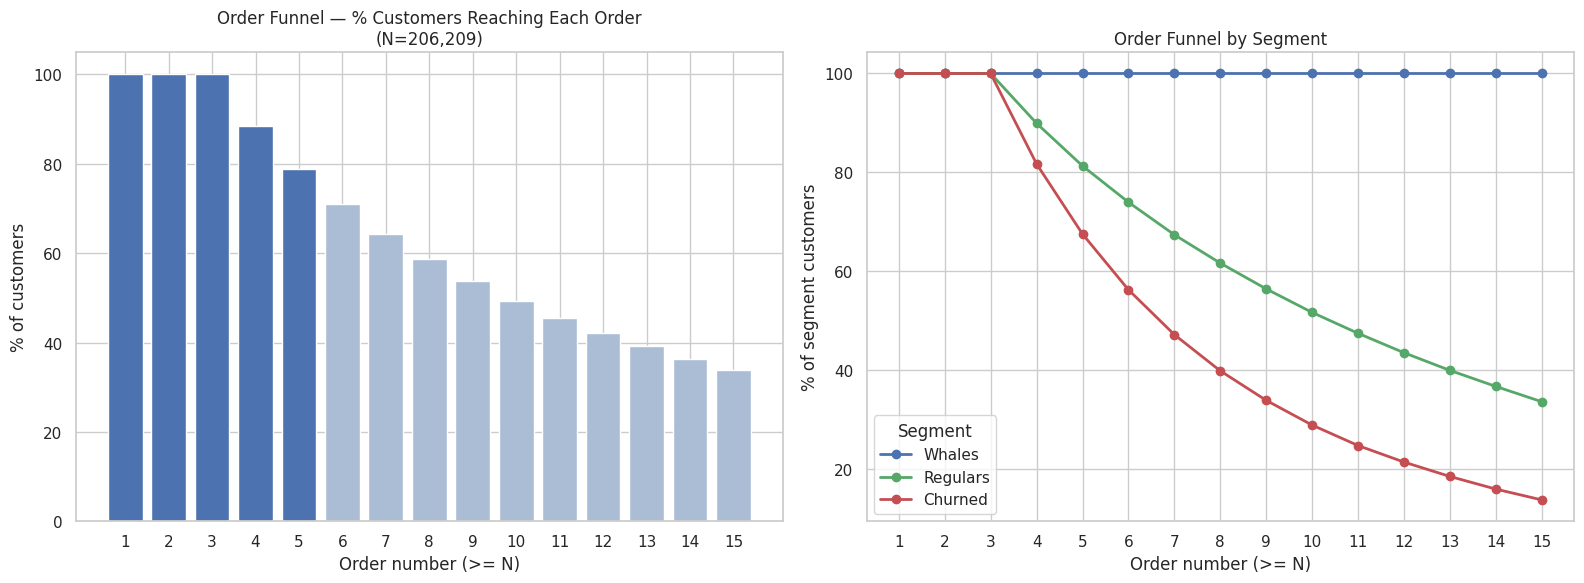

Overall funnel table:


,order_n,customers_reached,pct_of_total,drop_off_pct
0,1,206209,1.00,0.00
1,2,206209,1.00,0.00
2,3,206209,1.00,0.12
3,4,182223,0.88,0.10
4,5,162633,0.79,0.08
5,6,146468,0.71,0.07
6,7,132618,0.64,0.06
7,8,120918,0.59,0.05
8,9,110728,0.54,0.04
9,10,101696,0.49,0.04


Big drop-off points (>5%):


,order_n,pct_of_total,drop_off_pct
2,3,1.00,0.12
3,4,0.88,0.10
4,5,0.79,0.08
5,6,0.71,0.07
6,7,0.64,0.06


In [28]:
# --- Order Funnel ---
FUNNEL_MAX_ORDER = 15  # show up to order #15

# Customer max order number (total_orders per customer)
user_max_order = (
    df.groupby("user_id", observed=False)["order_number"]
    .max()
    .reset_index()
    .rename(columns={"order_number": "max_order"})
    .merge(rfm[["user_id", "segment"]], on="user_id", how="left")
)
user_max_order["segment"] = user_max_order["segment"].fillna("Unknown")

total_customers = user_max_order["user_id"].nunique()

# Overall funnel: % of customers with max_order >= n
funnel_steps = range(1, FUNNEL_MAX_ORDER + 1)
funnel = pd.DataFrame(
    {
        "order_n": list(funnel_steps),
        "customers_reached": [
            (user_max_order["max_order"] >= n).sum() for n in funnel_steps
        ],
    }
)
funnel["pct_of_total"] = funnel["customers_reached"] / total_customers
funnel["drop_off_pct"] = funnel["pct_of_total"].diff(-1).clip(lower=0)

# Segment funnel
seg_funnel_rows = []
for seg in SEGMENT_ORDER + ["Unknown"]:
    seg_users = user_max_order[user_max_order["segment"] == seg]
    n_seg = len(seg_users)
    if n_seg == 0:
        continue
    for n in funnel_steps:
        seg_funnel_rows.append(
            {
                "segment": seg,
                "order_n": n,
                "pct_reached": (seg_users["max_order"] >= n).sum() / n_seg,
            }
        )
seg_funnel = pd.DataFrame(seg_funnel_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall funnel bar chart
bar_colors = ["#4C72B0" if n <= 5 else "#AABDD4" for n in funnel["order_n"]]
axes[0].bar(funnel["order_n"], funnel["pct_of_total"] * 100, color=bar_colors, edgecolor="white")
axes[0].set_title(f"Order Funnel — % Customers Reaching Each Order\n(N={total_customers:,})")
axes[0].set_xlabel("Order number (>= N)")
axes[0].set_ylabel("% of customers")
axes[0].set_xticks(list(funnel_steps))

# Segment funnel line chart
seg_palette = dict(zip(SEGMENT_ORDER, ["#4C72B0", "#55A868", "#C44E52"]))
for seg in SEGMENT_ORDER:
    seg_data = seg_funnel[seg_funnel["segment"] == seg]
    if not seg_data.empty:
        axes[1].plot(
            seg_data["order_n"],
            seg_data["pct_reached"] * 100,
            marker="o",
            label=seg,
            color=seg_palette.get(seg),
            linewidth=2,
        )
axes[1].set_title("Order Funnel by Segment")
axes[1].set_xlabel("Order number (>= N)")
axes[1].set_ylabel("% of segment customers")
axes[1].set_xticks(list(funnel_steps))
axes[1].legend(title="Segment")

plt.tight_layout()
plt.show()

show_df(funnel, title="Overall funnel table:")

# Key drop-off points (drop > 5%)
big_drops = funnel[funnel["drop_off_pct"] > 0.05].copy()
show_df(big_drops[["order_n", "pct_of_total", "drop_off_pct"]], title="Big drop-off points (>5%):")

### 6.3 First Purchase Category (Gateway Category)

หา "gateway category" ที่พาลูกค้าใหม่เข้าสู่การเป็น Whales

- Top departments/aisles ในออร์เดอร์แรก (`order_number = 1`)
- เปรียบเทียบตาม segment
- Conversion insight: gateway category ไหนมีสัดส่วนกลายเป็น Whales สูง

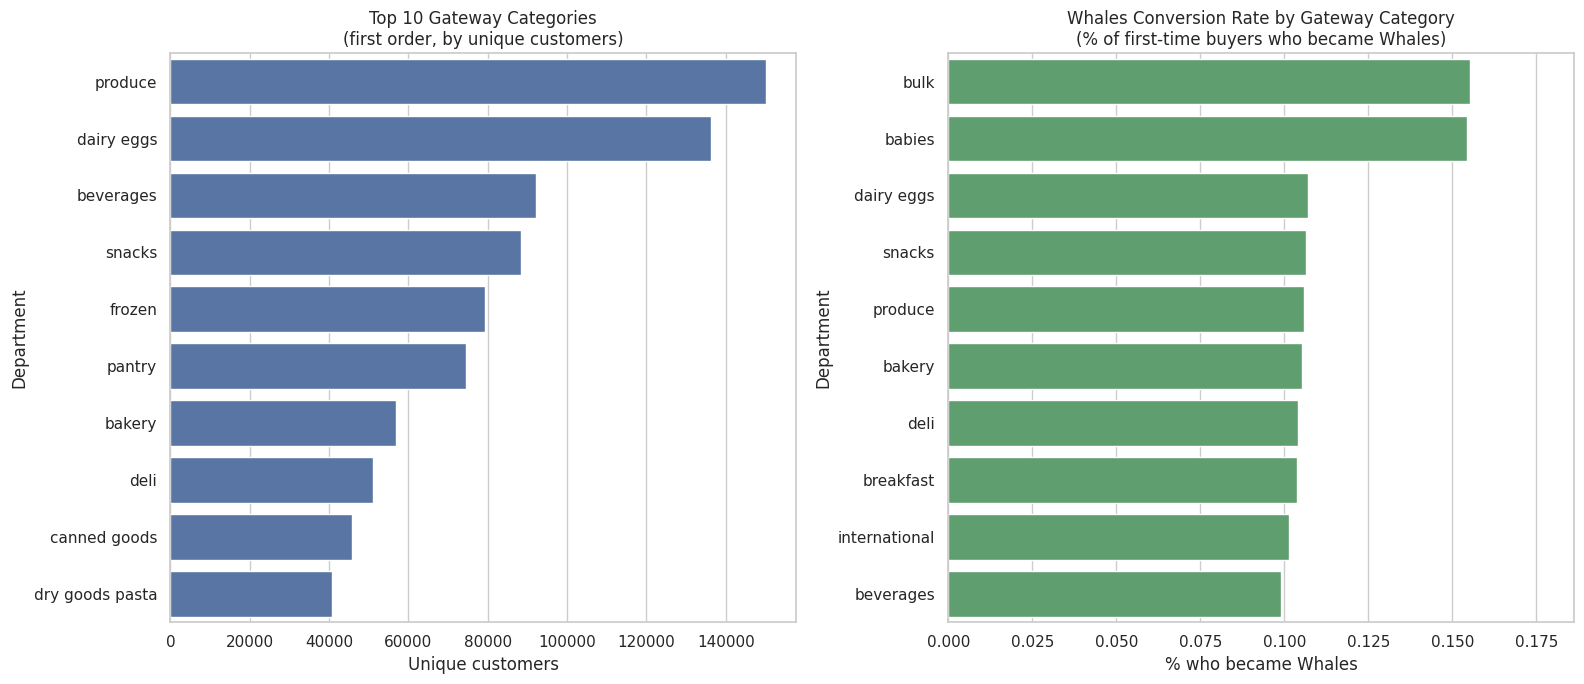

Overall top gateway categories (department):


,department,customers,order_lines,pct_of_new_customers
0,produce,150245,584384,0.73
1,dairy eggs,136272,333030,0.66
2,beverages,92264,167618,0.45
3,snacks,88331,180909,0.43
4,frozen,79311,158323,0.38
5,pantry,74426,128268,0.36
6,bakery,56870,75541,0.28
7,deli,51136,70099,0.25
8,canned goods,45911,73766,0.22
9,dry goods pasta,40797,60982,0.20


Top gateway categories by segment:


,segment,department,customers,pct_in_segment
0,Whales,produce,15903,0.16
1,Whales,dairy eggs,14576,0.15
2,Whales,snacks,9412,0.09
3,Whales,beverages,9127,0.09
4,Whales,frozen,7599,0.08
5,Whales,pantry,7314,0.07
6,Whales,bakery,5986,0.06
7,Whales,deli,5325,0.05
8,Whales,canned goods,4145,0.04
9,Whales,dry goods pasta,3928,0.04


Whales conversion rate by gateway category:


,department,whale_conversion_rate
0,bulk,0.16
1,babies,0.15
2,dairy eggs,0.11
3,snacks,0.11
4,produce,0.11
5,bakery,0.11
6,deli,0.10
7,breakfast,0.10
8,international,0.10
9,beverages,0.10


In [29]:
# --- First Purchase Category ---
TOP_N_GATEWAY = 10
GATEWAY_COL = "department"  # switch to "aisle" for finer granularity

first_order_df = df[df["order_number"] == 1].copy()

# Ensure department/aisle column exists
if GATEWAY_COL not in first_order_df.columns:
    product_dim_gw = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE, project_root=PROJECT_ROOT
    )[["product_id", GATEWAY_COL]]
    first_order_df = first_order_df.merge(product_dim_gw, on="product_id", how="left")

first_order_df[GATEWAY_COL] = first_order_df[GATEWAY_COL].fillna("Unknown")

# 1) Overall top gateway categories
gateway_overall = (
    first_order_df.groupby(GATEWAY_COL, observed=False)
    .agg(customers=("user_id", "nunique"), order_lines=("product_id", "count"))
    .reset_index()
    .sort_values("customers", ascending=False)
    .head(TOP_N_GATEWAY)
    .reset_index(drop=True)
)
gateway_overall["pct_of_new_customers"] = (
    gateway_overall["customers"] / first_order_df["user_id"].nunique()
)

# 2) Gateway by segment — which category did each segment start with?
rfm_segment = rfm[["user_id", "segment"]].copy()
if "segment" in first_order_df.columns:
    first_order_seg = first_order_df.drop(columns=["segment"]).merge(
        rfm_segment, on="user_id", how="left"
    )
else:
    first_order_seg = first_order_df.merge(rfm_segment, on="user_id", how="left")

first_order_seg["segment"] = first_order_seg["segment"].fillna("Unknown")

gateway_by_segment = (
    first_order_seg.groupby(["segment", GATEWAY_COL], observed=False)
    .agg(customers=("user_id", "nunique"))
    .reset_index()
)
seg_totals = gateway_by_segment.groupby("segment", observed=False)["customers"].transform("sum")
gateway_by_segment["pct_in_segment"] = gateway_by_segment["customers"] / seg_totals

top_gateway_by_segment = (
    gateway_by_segment.sort_values(["segment", "customers"], ascending=[True, False])
    .groupby("segment", observed=False)
    .head(TOP_N_GATEWAY)
    .reset_index(drop=True)
)

# 3) Conversion: for each gateway category, what % ended up as Whales?
whales_first = (
    first_order_seg.groupby([GATEWAY_COL, "segment"], observed=False)
    .agg(customers=("user_id", "nunique"))
    .reset_index()
)
cat_totals = whales_first.groupby(GATEWAY_COL, observed=False)["customers"].transform("sum")
whales_first["pct_in_cat"] = whales_first["customers"] / cat_totals

whale_conversion = (
    whales_first[whales_first["segment"] == "Whales"]
    [[GATEWAY_COL, "pct_in_cat"]]
    .rename(columns={"pct_in_cat": "whale_conversion_rate"})
    .sort_values("whale_conversion_rate", ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=gateway_overall,
    x="customers",
    y=GATEWAY_COL,
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title(f"Top {TOP_N_GATEWAY} Gateway Categories\n(first order, by unique customers)")
axes[0].set_xlabel("Unique customers")
axes[0].set_ylabel(GATEWAY_COL.title())

# Whales conversion rate by gateway category (top 10)
top_whale_conv = whale_conversion.head(TOP_N_GATEWAY)
sns.barplot(
    data=top_whale_conv,
    x="whale_conversion_rate",
    y=GATEWAY_COL,
    color="#55A868",
    ax=axes[1],
)
axes[1].set_title(f"Whales Conversion Rate by Gateway Category\n(% of first-time buyers who became Whales)")
axes[1].set_xlabel("% who became Whales")
axes[1].set_ylabel(GATEWAY_COL.title())
if not top_whale_conv.empty:
    axes[1].set_xlim(0, top_whale_conv["whale_conversion_rate"].max() * 1.2)

plt.tight_layout()
plt.show()

show_df(gateway_overall, title=f"Overall top gateway categories ({GATEWAY_COL}):")
show_df(top_gateway_by_segment, title="Top gateway categories by segment:")
show_df(whale_conversion, title="Whales conversion rate by gateway category:")

## 7) Trend Deep Dive (User & Product)

In [ ]:
# --- User trend + Product trend (Top N + Share) ---
TREND_FREQ = "W"  # use "M" for monthly
TOP_N_PRODUCTS = 8
TOP_N_DEPARTMENTS = 6

trend_df = df.copy()
trend_df["period"] = trend_df["order_date"].dt.to_period(TREND_FREQ).dt.to_timestamp()

# User trend metrics
user_trend = (
    trend_df.groupby("period", observed=False)
    .agg(
        active_users=("user_id", "nunique"),
        orders=("order_id", "nunique"),
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)
user_trend["orders_per_active_user"] = user_trend["orders"] / user_trend["active_users"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=user_trend, x="period", y="active_users", marker="o", ax=axes[0], label="active_users")
sns.lineplot(data=user_trend, x="period", y="orders_per_active_user", marker="o", ax=axes[0], label="orders_per_active_user")
axes[0].set_title(f"User Trend ({TREND_FREQ})")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Count / Ratio")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=user_trend, x="period", y="reorder_rate", marker="o", ax=axes[1], color="#C44E52")
axes[1].set_title(f"Reorder Rate Trend ({TREND_FREQ})")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Reorder Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

show_df(user_trend, title="User trend summary:")

# Product trend prep: ensure department exists
if "department" not in trend_df.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", "department"]]
    trend_df = trend_df.merge(product_dim, on="product_id", how="left")

period_total_lines = (
    trend_df.groupby("period", observed=False)
    .size()
    .rename("total_lines_period")
    .reset_index()
)

# Top N products by overall order lines
top_products = (
    trend_df["product_name"].value_counts().head(TOP_N_PRODUCTS).index.tolist()
)
product_period = (
    trend_df[trend_df["product_name"].isin(top_products)]
    .groupby(["period", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
    .merge(period_total_lines, on="period", how="left")
)
product_period["share_of_total"] = product_period["order_lines"] / product_period["total_lines_period"]

# Top N departments by overall order lines
top_departments = (
    trend_df["department"].dropna().value_counts().head(TOP_N_DEPARTMENTS).index.tolist()
)
dept_period = (
    trend_df[trend_df["department"].isin(top_departments)]
    .groupby(["period", "department"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
    .merge(period_total_lines, on="period", how="left")
)
dept_period["share_of_total"] = dept_period["order_lines"] / dept_period["total_lines_period"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.lineplot(
    data=product_period,
    x="period",
    y="order_lines",
    hue="product_name",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title(f"Top {TOP_N_PRODUCTS} Products: Order Lines Trend ({TREND_FREQ})")
axes[0, 0].set_xlabel("Period")
axes[0, 0].set_ylabel("Order lines")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=product_period,
    x="period",
    y="share_of_total",
    hue="product_name",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"Top {TOP_N_PRODUCTS} Products: Share of Total ({TREND_FREQ})")
axes[0, 1].set_xlabel("Period")
axes[0, 1].set_ylabel("Share of total")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=dept_period,
    x="period",
    y="order_lines",
    hue="department",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title(f"Top {TOP_N_DEPARTMENTS} Departments: Order Lines Trend ({TREND_FREQ})")
axes[1, 0].set_xlabel("Period")
axes[1, 0].set_ylabel("Order lines")
axes[1, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=dept_period,
    x="period",
    y="share_of_total",
    hue="department",
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title(f"Top {TOP_N_DEPARTMENTS} Departments: Share of Total ({TREND_FREQ})")
axes[1, 1].set_xlabel("Period")
axes[1, 1].set_ylabel("Share of total")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

show_df(product_period.sort_values(["product_name", "period"]), title="Product trend sample:")
show_df(dept_period.sort_values(["department", "period"]), title="Department trend sample:")

## 8) Distribution Diagnostics (Histogram Supplements)

ใช้ histogram เพื่ออ่าน shape ของการกระจาย (ไม่ใช่ time trend)
- `days_since_prior_order`
- `orders_per_user`
- `product_growth_rate` ข้ามช่วงเวลา

In [ ]:
# --- Histogram supplements ---

# 1) Distribution of days_since_prior_order
days_dist = df["days_since_prior_order"].dropna()

# 2) Distribution of order frequency per user
user_order_freq = (
    df.groupby("user_id", observed=False)["order_id"]
    .nunique()
    .rename("orders_per_user")
)

# 3) Distribution of product growth rate between periods
growth_base = (
    trend_df.groupby(["period", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)
growth_base = growth_base.sort_values(["product_name", "period"])
growth_base["product_growth_rate"] = growth_base.groupby("product_name", observed=False)["order_lines"].pct_change()

# Keep finite growth values for histogram
growth_values = growth_base["product_growth_rate"].replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(days_dist, bins=20, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution: days_since_prior_order")
axes[0].set_xlabel("Days since prior order")
axes[0].set_ylabel("Frequency")

sns.histplot(user_order_freq, bins=20, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution: orders per user")
axes[1].set_xlabel("Orders per user")
axes[1].set_ylabel("Frequency")

sns.histplot(growth_values, bins=20, kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title(f"Distribution: product growth rate ({TREND_FREQ})")
axes[2].set_xlabel("Growth rate (period-over-period)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

show_df(user_order_freq.describe().to_frame(name="orders_per_user"), title="orders_per_user summary:")
show_df(growth_values.describe().to_frame(name="product_growth_rate"), title="product_growth_rate summary:")

# --- Executive summary block (auto-refresh after re-run) ---
segment_snapshot = (
    rfm.groupby("segment", observed=False)
    .agg(
        users=("user_id", "nunique"),
        median_total_orders=("total_orders", "median"),
        median_reorder_ratio=("reorder_ratio", "median"),
        median_days_since_last_order=("days_since_last_order", "median"),
    )
    .reset_index()
)
segment_snapshot["user_share"] = segment_snapshot["users"] / segment_snapshot["users"].sum()

print("\n=== Executive Summary (Quick Read) ===")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
print(f"Rows: {len(df):,} | Users: {df['user_id'].nunique():,} | Orders: {df['order_id'].nunique():,}")
print(f"Date range: {df['order_date'].min().date()} -> {df['order_date'].max().date()}")
show_df(segment_snapshot, title="Segment snapshot:")

top5 = df["product_name"].value_counts().head(5).rename("order_lines").to_frame()
show_df(top5, title="Top 5 products overall (order lines):")

print("Overall reorder rate:", f"{df['reordered'].mean():.2%}")
print("Median days_since_prior_order:", f"{df['days_since_prior_order'].median():.1f}")

## 9) Executive Summary (Interpretation Template)

ใช้ checklist นี้ตอนสรุปผลประชุม/พรีเซนต์

- Segment story: Whales / Regulars / Churned ต่างกันที่อะไร (order frequency, reorder, recency)
- Time-slot story: วันและชั่วโมงไหนมีทั้ง volume และ reorder สูง
- Category story: หมวดไหน repeat สูง และหมวดไหนมูลค่าตะกร้าสูง
- Risk story: threshold churn ที่เหมาะกับธุรกิจ และ segment ไหนเสี่ยงสุด
- Action story: แผนที่ควรทำทันที 3 อย่าง (retain Whales, grow Regulars, win-back Churned)

หมายเหตุ: ให้รัน cell summary ก่อนหน้าเพื่ออัปเดตตัวเลขล่าสุดทุกครั้ง